In [8]:
!wget -q https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip
!unzip -q diabetes+130-us+hospitals+for+years+1999-2008.zip

replace diabetic_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace IDS_mapping.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: no


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

In [10]:
df = pd.read_csv('diabetic_data.csv')
df.shape

(101766, 50)

In [11]:
df['readmitted'].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [12]:
features = ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
data = df[features + ['readmitted']].copy()
data = data.replace('?', np.nan)
data['age'] = data['age'].str.extract(r'(\d+)-(\d+)').astype(float).mean(axis=1)
data = data.dropna()
data['readmitted'] = (data['readmitted'] == '<30').astype(int)
data.head()

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted
0,5.0,1,41,0,1,0,0,0,1,0
1,15.0,3,59,0,18,0,0,0,9,0
2,25.0,2,11,5,13,2,0,1,6,0
3,35.0,2,44,1,16,0,0,0,7,0
4,45.0,1,51,0,8,0,0,0,5,0


In [13]:
X = data[features]
y = data['readmitted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [16]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
print('ROC-AUC:', roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6402071878891632
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.48      0.01      0.03      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.48     20354
weighted avg       0.84      0.89      0.84     20354



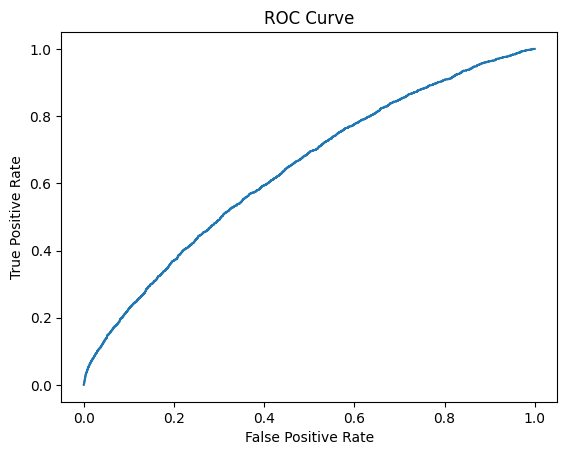

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [18]:
print(confusion_matrix(y_test, y_pred))

[[18049    34]
 [ 2239    32]]


In [19]:
results = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]})
results.sort_values('Coefficient', ascending=False)

,Feature,Coefficient
7,number_inpatient,0.343126
8,number_diagnoses,0.081289
1,time_in_hospital,0.066652
4,num_medications,0.057398
0,age,0.055619
6,number_emergency,0.029333
2,num_lab_procedures,0.000169
5,number_outpatient,-0.003410
3,num_procedures,-0.040471


A false negative means a patient who is likely to be readmitted within 30 days is predicted as low risk. This can delay follow-up care.

A false positive means a patient who is not readmitted within 30 days is predicted as high risk. This can use extra monitoring and hospital resources.

False negatives can have a higher clinical cost because missing a high-risk patient may affect timely care.